### NER

Un modelo de **Reconocimiento de Entidades Nombradas** (NER, por sus siglas en inglés) es, fundamentalmente, un problema de clasificación de secuencias. El objetivo es asignar una etiqueta $y_i$ a cada token $x_i$ de una secuencia de entrada $X = (x_1, x_2, \dots, x_n)$.



Cada palabra o token $x_i$ se proyecta en un espacio vectorial continuo (embedding) de dimensión $d$:$$e_i = \text{Embed}(x_i) \in \mathbb{R}^d$$

La secuencia completa se representa como una matriz $E = [e_1, e_2, \dots, e_n] \in \mathbb{R}^{n \times d}$.2. Codificación ContextualEl modelo (usualmente un Transformer como BERT) transforma estas representaciones mediante múltiples capas de atención para capturar el contexto bidireccional. La salida del codificador es una secuencia de vectores ocultos $H = [h_1, h_2, \dots, h_n]$, donde cada $h_i \in \mathbb{R}^k$ contiene información sobre la posición del token en la oración.La atención escalada producto punto se define como:$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Capa de Clasificación (Emisión)Para cada vector oculto $h_i$, el modelo calcula un vector de logits $z_i \in \mathbb{R}^L$ (donde $L$ es el número de etiquetas, ej: B-PER, I-PER, O):$$z_i = W_{cls} h_i + b_{cls}$$Luego, se convierte a una distribución de probabilidad usando Softmax:$$P(y_i = j | X) = \frac{\exp(z_{i,j})}{\sum_{k=1}^L \exp(z_{i,k})}$$

Inferencia con CRF en modelos NER robustos, no se clasifica cada token de forma independiente (lo cual violaría dependencias de etiquetas, como que un I-PER debe seguir a un B-PER). Se utiliza un Conditional Random Field (CRF) para modelar la probabilidad de la secuencia completa $Y = (y_1, \dots, y_n)$.La probabilidad de una secuencia de etiquetas dada la entrada $X$ es:$$P(Y|X) = \frac{\exp(\sum_{i=1}^n \psi_i(y_i, y_{i-1}, X))}{\sum_{Y' \in \mathcal{Y}} \exp(\sum_{i=1}^n \psi_i(y'_i, y'_{i-1}, X))}$$Donde $\psi_i$ es una función de potencial que considera tanto el score de emisión (del modelo) como el score de transición entre la etiqueta anterior $y_{i-1}$ y la actual $y_i$.

EntrenamientoSe minimiza la Negative Log-Likelihood (NLL) de la secuencia de etiquetas correcta $Y_{gold}$:$$\mathcal{L} = -\sum_{i=1}^N \log P(Y_{gold} | X)$$El modelo ajusta sus parámetros $W$ mediante retropropagación (backpropagation) para maximizar la probabilidad de que la secuencia predicha coincida con la secuencia anotada manualmente.



### Aplicaciones 

Las aplicaciones del reconocimiento de entidades nombradas (NER) son fundamentales en cualquier sistema que necesite extraer datos estructurados a partir de texto no estructurado. Dado que el NER identifica conceptos clave como nombres, lugares, fechas y entidades técnicas, sus usos son variados:

1. Sector Financiero y Legal
Análisis de Contratos: Extracción automática de fechas de vencimiento, nombres de empresas, montos financieros y cláusulas legales.

Gestión de Riesgos: Identificación de entidades en noticias o informes financieros para detectar eventos que afecten el mercado.

Código: $P(event | news) = \text{ExtractEntities}(news) \implies \text{RiskScore}$

2. Salud y Biomedicina (BioNER)
Análisis de Historias Clínicas: Identificación de nombres de pacientes (anonimización), síntomas, nombres de medicamentos y dosis.

Investigación Farmacéutica: Extracción de interacciones gen-proteína a partir de miles de artículos científicos para acelerar el descubrimiento de fármacos.

Código: $\text{Entities}_{bio} = \{ \text{Gene, Protein, Disease, Drug} \}$

3. Servicio al Cliente y Chatbots
Clasificación de Intentos: Extraer datos específicos (ej: "quiero un vuelo a París el 12 de mayo") donde "París" es LOC (Location) y "12 de mayo" es DATE.

Soporte Técnico: Extraer números de serie, modelos de dispositivos y descripciones de fallos para agilizar el envío a la base de conocimientos correcta.

4. Búsqueda y Gestión de Contenido
Indexación Semántica: En lugar de buscar por palabras clave exactas, un motor puede buscar por entidades (ej: buscar todos los artículos que mencionen a un "CEO" específico).

Resumen Automático: Identificar quiénes son los sujetos principales en una noticia para generar resúmenes coherentes.

5. Análisis de Sentimiento con Enfoque en Entidades
A veces no basta con saber si un texto es positivo o negativo; es necesario saber sobre qué es la opinión.

Ejemplo: "El procesador del modelo X es increíble, pero la batería es pésima."

Un modelo NER separa el análisis: [modelo X, procesador] -> Positivo, [modelo X, batería] -> Negativo.

In [ ]:
from pathlib import Path
from collections import defaultdict
import torch
from torch.utils.data import Dataset, DataLoader

from pathlib import Path
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
from pathlib import Path

import matplotlib.pyplot as plt


### Carga de datos

In [2]:
@torch.no_grad()
def evaluate(model, loader, device, ignore_index=-100):
    model.eval()
    total, correct, losses = 0, 0, []
    criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)
    for tokens, labels, mask in loader:
        tokens, labels, mask = tokens.to(device), labels.to(device), mask.to(device)
        logits = model(tokens, mask)  # (B,S,C)
        loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
        losses.append(loss.item())
        preds = logits.argmax(dim=-1)
        valid = labels.ne(ignore_index)
        correct += (preds[valid] == labels[valid]).sum().item()
        total += valid.sum().item()
    acc = correct / max(1, total)
    return float(np.mean(losses)), acc

In [3]:
def read_conll_sentences(path: str | Path):
    sents = []
    toks, labs = [], []
    with open(path, encoding="utf-8") as f:
        for raw in f:
            line = raw.rstrip("\n")
            if not line:
                if toks:
                    sents.append((toks, labs))
                    toks, labs = [], []
                continue
            if line.startswith("-DOCSTART-"):
                continue
            parts = line.split()
            if len(parts) >= 4:
                token, label = parts[0], parts[3]
            else:  # tolera archivos con 2 columnas (token label)
                token, label = parts[0], parts[-1]
            toks.append(token)
            labs.append(label)
    if toks:
        sents.append((toks, labs))
    return sents

class CoNLLDatasetSimple(Dataset):
    """
    Lee CoNLL (.conll/.txt) y regresa:
      - tokens_ids: (max_len,) long
      - labels_ids: (max_len,) long con -100 en PAD
      - padding_mask: (max_len,) bool (True en PAD)
    Requiere:
      - word_to_idx (por ej. de fastText .vec con <PAD>=0, <UNK>=1)
      - class_mapping (BIO -> int)
      - max_len
    """
    def __init__(self, path, word_to_idx, class_mapping, max_len=128, lowercase=True, pad_token="<PAD>"):
        self.sents = read_conll_sentences(path)
        self.w2i = defaultdict(lambda: self.w2i.get("<UNK>", 1), word_to_idx)
        self.class_map = class_mapping
        self.max_len = max_len
        self.lowercase = lowercase
        self.PAD_IDX = word_to_idx[pad_token]

    def __len__(self):
        return len(self.sents)

    def _norm(self, t: str) -> str:
        return t.strip().lower() if self.lowercase else t.strip()

    def __getitem__(self, idx):
        toks, labs = self.sents[idx]
        # normaliza
        toks_norm = [self._norm(t) for t in toks]

        # mapea a ids
        tok_ids = [self.w2i[t] for t in toks_norm]
        lab_ids = [self.class_map[y] for y in labs]

        # recorta
        tok_ids = tok_ids[:self.max_len]
        lab_ids = lab_ids[:self.max_len]

        # pad
        pad_len = self.max_len - len(tok_ids)
        if pad_len > 0:
            tok_ids += [self.PAD_IDX] * pad_len
            lab_ids += [-100] * pad_len  # ignora en la loss

        tokens = torch.tensor(tok_ids, dtype=torch.long)
        labels = torch.tensor(lab_ids, dtype=torch.long)
        padding_mask = (tokens == self.PAD_IDX)  # bool

        return tokens, labels, padding_mask

In [4]:
def collate_fixed(batch):
    tokens = torch.stack([b[0] for b in batch], dim=0)   # (B,S)
    labels = torch.stack([b[1] for b in batch], dim=0)   # (B,S)
    mask   = torch.stack([b[2] for b in batch], dim=0)   # (B,S)
    return tokens.long(), labels.long(), mask.bool()

In [5]:

def cargar_embeddings(path_vec, pad_token="<PAD>", unk_token="<UNK>", max_tokens=None):
    """
    Lee un archivo .vec de fastText  devuelve:
        • word_to_idx:  dict {palabra: índice}
        • embeddings:   torch.FloatTensor (vocab, dim)
    Si `max_tokens` no es None, corta la lectura tras ese nº de palabras (útil para pruebas rápidas).
    """
    idx_to_word = [pad_token, unk_token]
    vectores = []

    with open(path_vec, "r", encoding="utf-8", newline="\n", errors="ignore") as f:
        # Primera línea: "2000000 300"
        header = f.readline().strip().split()
        dim = int(header[1])                         # 300 en cc.es.300.vec

        for n, line in enumerate(f, start=1):
            if max_tokens and n > max_tokens:
                break
            word, *vec = line.rstrip().split(" ")
            idx_to_word.append(word)
            vectores.append(list(map(float, vec)))

    # Añadir vectores especiales
    vectores.insert(0, [0.0] * dim)                 # PAD = 0
    vectores.insert(1, np.random.uniform(-0.05, 0.05, size=dim))  # UNK

    embeddings = torch.tensor(vectores, dtype=torch.float32)
    word_to_idx = {w: i for i, w in enumerate(idx_to_word)}
    return word_to_idx, embeddings


In [6]:
word_to_idx, embeddings = cargar_embeddings(r"C:\\Users\\ovill\\OneDrive\\Documentos\\NER\\cc.es.300.vec\\cc.es.300.vec", max_tokens=50000)

C:\Users\ovill\AppData\Local\Temp\ipykernel_32024\1352466187.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  embeddings = torch.tensor(vectores, dtype=torch.float32)


In [7]:
## Borrar 

class_mapping = {
    "O": 0,
    "B-NOMBRE_EMPRESA": 1, "I-NOMBRE_EMPRESA": 2,
    "B-RFC_EMPRESA": 3, "I-RFC_EMPRESA": 4,
    "B-DOMICILIO_EMPRESA": 5, "I-DOMICILIO_EMPRESA": 6,
    "B-ID_EMPLEADO": 7, "I-ID_EMPLEADO": 8,
    "B-NOMBRE_EMPLEADO": 9, "I-NOMBRE_EMPLEADO": 10,
    "B-RFC_EMPLEADO": 11, "I-RFC_EMPLEADO": 12,
    "B-CURP_EMPLEADO": 13, "I-CURP_EMPLEADO": 14,
    "B-FECHA_INICIO_LABORAL": 15, "I-FECHA_INICIO_LABORAL": 16, # La que causó el error
    "B-NSS": 17, "I-NSS": 18,
    "B-EJERCICIO": 19, "I-EJERCICIO": 20,
    "B-PERIODO_PAGO": 21, "I-PERIODO_PAGO": 22,
    "B-DIAS_PAGADOS": 23, "I-DIAS_PAGADOS": 24,
    "B-FECHA_PAGO": 25, "I-FECHA_PAGO": 26,
    "B-PUESTO": 27, "I-PUESTO": 28,
    "B-TOTAL_PERCEPCIONES": 29, "I-TOTAL_PERCEPCIONES": 30,
    "B-TOTAL_DEDUCCIONES": 31, "I-TOTAL_DEDUCCIONES": 32,
    "B-SALARIO_NETO": 33, "I-SALARIO_NETO": 34
}

In [10]:
train_ds = CoNLLDatasetSimple(r"C:\Users\ovill\OneDrive\Escritorio\train_sintetico.txt",
                               word_to_idx, class_mapping, max_len=128)

vald_ds = CoNLLDatasetSimple(r"C:\Users\ovill\OneDrive\Escritorio\test_sintetico.txt",
                               word_to_idx, class_mapping, max_len=128)

In [11]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fixed)
valid_loader = DataLoader(vald_ds, batch_size=16, shuffle=True, collate_fn=collate_fixed)

In [12]:
batch = next(iter(train_loader))
tokens, labels, mask = batch

### Estructura del modelo

In [13]:

# =============================================================================
# 3) Bloques del Transformer (tu estructura con ajustes)
# =============================================================================

class PositionalEncodings(nn.Module):
    """Attention is All You Need positional encoding layer"""
    def __init__(self, seq_len, d_model, p_dropout):
        super().__init__()
        token_positions = torch.arange(seq_len).view(-1, 1)
        dim_positions   = torch.arange(d_model).view(1, -1)
        angles = token_positions / (10000 ** ((2 * dim_positions) / d_model))

        encodings = torch.zeros(1, seq_len, d_model, dtype=torch.float32)
        encodings[0, :, ::2] = torch.sin(angles[:, ::2])
        encodings[0, :, 1::2] = torch.cos(angles[:, 1::2])
        encodings.requires_grad = False
        self.register_buffer("positional_encodings", encodings)
        self.dropout = nn.Dropout(p_dropout)

    def forward(self, x):  # x: (B,S,D)
        S = x.size(1)
        x = x + self.positional_encodings[:, :S, :]
        return self.dropout(x)

class ScaleNorm(nn.Module):
    """Scale Norm layer (mejora estabilidad)"""
    def __init__(self, scale, eps=1e-5):
        super().__init__()
        self.scale = nn.Parameter(torch.tensor(scale, dtype=torch.float32))
        self.register_buffer("eps", torch.tensor(eps, dtype=torch.float32))
    def forward(self, x):
        norm = self.scale / torch.norm(x, dim=-1, keepdim=True).clamp(min=float(self.eps))
        return x * norm

class MultiHeadAttention(nn.Module):
    """Multi-Head Self-Attention (seq-first interno)"""
    def __init__(self, num_heads, d_model, p_dropout):
        super().__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"
        self.d_head = d_model // num_heads
        self.num_heads = num_heads
        self.qkv_matrices = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(3)])
        self.dropout = nn.Dropout(p_dropout)
        self.out_projection = nn.Linear(d_model, d_model)

    def self_attention(self, query, key, value, padd_mask=None):
        """
        query,key,value: (S,B,D)
        padd_mask: (B,S) bool (True=PAD)
        """
        seq_len, batch_size, d_model = query.shape
        mask_exp = None
        if padd_mask is not None:
            assert padd_mask.shape == (batch_size, seq_len), f"mask shape {padd_mask.shape}, esperado {(batch_size, seq_len)}"
            mask_exp = padd_mask.view(batch_size, 1, 1, seq_len) \
                                 .expand(-1, self.num_heads, -1, -1) \
                                 .reshape(batch_size * self.num_heads, 1, seq_len)  # (B*H,1,S)

        # (S,B,D) -> (B*H,S,d_head)
        def _prep(x):
            return x.contiguous().view(seq_len, batch_size * self.num_heads, self.d_head).transpose(0, 1)
        Q = _prep(query)
        K = _prep(key)
        V = _prep(value)

        attn_scores = torch.bmm(Q, K.transpose(1, 2)) / (self.d_head ** 0.5)  # (B*H,S,S)
        if mask_exp is not None:
            attn_scores.masked_fill_(mask_exp, float("-inf"))

        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        out = torch.bmm(attn_weights, V)  # (B*H,S,d_head)

        # (B*H,S,d_head) -> (S,B,D)
        out = out.transpose(1, 0).contiguous().view(seq_len, batch_size, d_model)
        return out, attn_weights

    def forward(self, query, key, value, padd_mask=None):
        # Proyecciones lineales
        query, key, value = [proj(inp) for proj, inp in zip(self.qkv_matrices, [query, key, value])]
        out, attn_w = self.self_attention(query, key, value, padd_mask)
        out = self.out_projection(out)
        return out, attn_w

class TransformerEncoderLayer(nn.Module):
    def __init__(self, num_heads, d_model, ff_dim, p_dropout):
        super().__init__()
        self.scale_norm_1 = ScaleNorm(d_model ** 0.5)
        self.mha = MultiHeadAttention(num_heads, d_model, p_dropout)
        self.dropout_1 = nn.Dropout(p_dropout)

        self.scale_norm_2 = ScaleNorm(d_model ** 0.5)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout_2 = nn.Dropout(p_dropout)

    def forward(self, x, padd_mask=None):  # x: (S,B,D)
        x1 = self.scale_norm_1(x)
        skip = x
        attn_out, attn_w = self.mha(x1, x1, x1, padd_mask)
        x = skip + self.dropout_1(attn_out)

        x2 = self.scale_norm_2(x)
        skip = x
        x = skip + self.dropout_2(self.ff(x2))
        return x, attn_w

class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, num_heads, d_model, ff_dim, p_dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(num_heads, d_model, ff_dim, p_dropout)
        for _ in range(num_layers)])
        self.out_norm = ScaleNorm(d_model ** 0.5)

    def forward(self, x, padd_mask=None):  # x: (S,B,D)
        attn_all = []
        for layer in self.layers:
            x, attn = layer(x, padd_mask)
            attn_all.append(attn)
        return self.out_norm(x), attn_all

class ResidualBlock(nn.Module):
    """Bloque residual sencillo por token"""
    def __init__(self, input_dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.LeakyReLU(),
            nn.Linear(input_dim, input_dim),
        )
    def forward(self, x):  # (B,S,D)
        return x + self.block(x)

class NERClassifier(nn.Module):
    """Modelo NER palabra-a-palabra con Transformer"""
    def __init__(self, config):
        super().__init__()
        num_classes = len(config["class_mapping"])
        num_layers  = config["num_of_transformer_layers"]
        d_model     = config["transformer_embedding_dim"]
        heads       = config["attention_heads"]
        ff_dim      = config["transformer_ff_dim"]
        dropout     = config["dropout"]

        # Embeddings fastText
        ruta = str(config["embeddings"]["path"])
        self.word_to_idx, pretrained = cargar_embeddings(ruta, max_tokens=config.get("max_vec_tokens", None))
        config["PAD_idx"] = self.word_to_idx["<PAD>"]
        config["embeddings"]["size"] = pretrained.size(1)
        emb_dim = pretrained.size(1)

        self.embedding_layer = nn.Embedding.from_pretrained(
            pretrained, freeze=True, padding_idx=config["PAD_idx"]
        )
        self.entry_mapping = nn.Linear(emb_dim, d_model)
        self.res_block = ResidualBlock(d_model)
        self.positional_encodings = PositionalEncodings(config["max_len"], d_model, dropout)
        self.transformer_encoder = TransformerEncoder(num_layers, heads, d_model, ff_dim, dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, padding_mask):  # x: (B,S)
        x = self.embedding_layer(x)                  # (B,S,emb)
        x = F.leaky_relu(self.entry_mapping(x))      # (B,S,D)
        x = F.leaky_relu(self.res_block(x))          # (B,S,D)
        x = self.positional_encodings(x)             # (B,S,D)
        x = x.permute(1, 0, 2)                       # -> (S,B,D) para el encoder
        x, _ = self.transformer_encoder(x, padding_mask)  # mask: (B,S) bool
        x = x.permute(1, 0, 2)                       # -> (B,S,D)
        return self.classifier(x)                    # (B,S,C)


### Entrenamiento del Modelo

In [14]:
config = {
        "embeddings": {
            # ➜ Ruta al .vec (es o en)
            "path": Path(r"C:\\Users\\ovill\\OneDrive\\Documentos\\NER\\cc.es.300.vec\\cc.es.300.vec"),
            "size": 300
        },
        "class_mapping": class_mapping
        ,
        "PAD_idx": 0,         # se redefine tras cargar embeddings
        "max_len": 128,

        "num_of_transformer_layers": 2,
        "transformer_embedding_dim": 256,
        "transformer_ff_dim": 256,
        "attention_heads": 8,
        "dropout": 0.3,

        "seed": 42,
        "batch_size": {"train": 8, "validation": 32},
        "dataset_path": {
            # Cambia a tus rutas reales (eng.testa / eng.testb)
            "train": r"C:\Users\ovill\OneDrive\Escritorio\train_sintetico.txt",
            "validation": r"C:\Users\ovill\OneDrive\Escritorio\test_sintetico.txt",
        },
        "train_config": {
            "learning_rate": 0.00075 , #0.000075,
            "l2_penalty": 0.3,
            "num_of_epochs": 50,
            "gradient_clipping": 0.8
        }
    }
device = "cuda" if torch.cuda.is_available() else "cpu"

In [15]:
model = NERClassifier(config).to(device)

In [16]:
lr = config["train_config"]["learning_rate"]
wd = config["train_config"]["l2_penalty"]
epochs = config["train_config"]["num_of_epochs"]
clip = config["train_config"]["gradient_clipping"]

In [17]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

In [18]:
class_w = config["train_config"].get("class_w")
if class_w is None:
        num_classes = len(config["class_mapping"])
        counts = np.zeros(num_classes, dtype=np.int64)
        for _, y, _ in train_loader:
            y_np = y.numpy()
            for c in range(num_classes):
                counts[c] += int((y_np == c).sum())
        freq = counts / max(1, counts.sum())
        with np.errstate(divide='ignore'):
            weights = np.log(1.0 / np.clip(freq, 1e-12, None))
        class_w = torch.tensor(weights, dtype=torch.float32, device=device)
else:
        class_w = torch.tensor(class_w, dtype=torch.float32, device=device)
        class_w = class_w / class_w.sum()

In [ ]:
train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

for ep in range(epochs):
        model.train()
        losses = []
        for tokens, labels, mask in train_loader:
            tokens, labels, mask = tokens.to(device), labels.to(device), mask.to(device)
            optimizer.zero_grad()
            logits = model(tokens, mask)  # (B,S,C)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1),
                                   weight=class_w, ignore_index=-100)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            losses.append(loss.item())

        train_loss, train_acc = evaluate(model, train_loader, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)


        print(f"Epoch {ep:02d} | "
              f"train_loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"valid_loss {valid_loss:.4f} acc {valid_acc:.4f}")


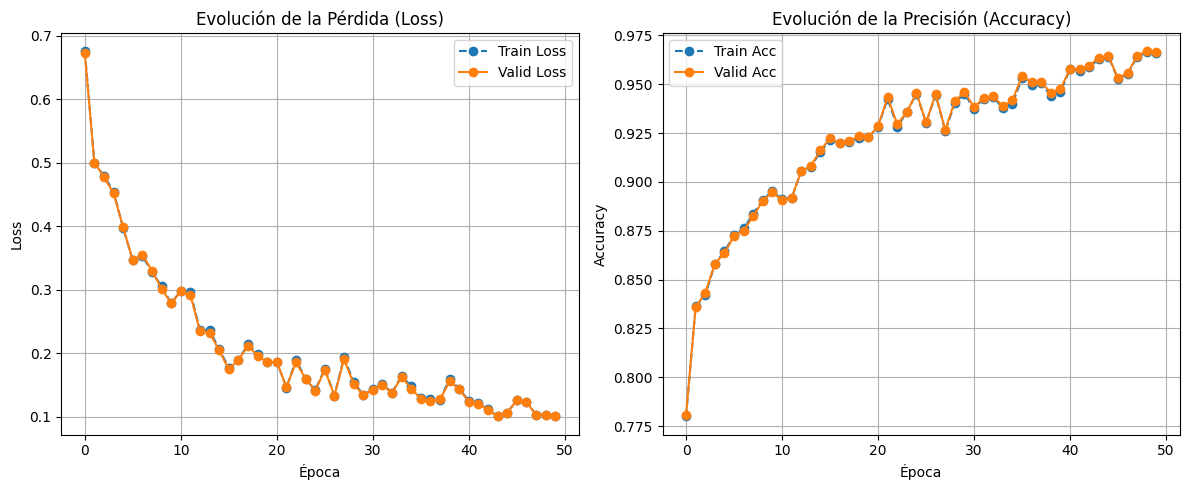

In [22]:


# Crear la figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de Loss
ax1.plot(train_losses, label='Train Loss', marker='o', linestyle='--')
ax1.plot(valid_losses, label='Valid Loss', marker='o', linestyle='-')
ax1.set_title('Evolución de la Pérdida (Loss)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Gráfico de Accuracy
ax2.plot(train_accs, label='Train Acc', marker='o', linestyle='--')
ax2.plot(valid_accs, label='Valid Acc', marker='o', linestyle='-')
ax2.set_title('Evolución de la Precisión (Accuracy)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [23]:
import re
import torch

def simple_tokenize(text: str):
    # tokens por palabra + signos (compatible con CoNLL)
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)

def bio_to_spans(tokens, tags):
    """
    Convierte BIO a spans robusto:
    - 'I-XXX' con tipo distinto al actual → se trata como 'B-XXX'
    - 'I-XXX' sin entidad abierta → se trata como 'B-XXX'
    Devuelve [{'text', 'type', 'start', 'end'}, ...]
    """
    spans = []
    cur_tokens, cur_type, start = [], None, None

    def flush(end_idx):
        nonlocal cur_tokens, cur_type, start, spans
        if cur_type is not None and cur_tokens:
            spans.append({
                "text": " ".join(cur_tokens),
                "type": cur_type,
                "start": start,
                "end": end_idx
            })
        cur_tokens, cur_type, start = [], None, None

    for i, (t, y) in enumerate(zip(tokens, tags)):
        if y.startswith("B-"):
            # cierra lo anterior y abre nuevo
            if cur_type is not None:
                flush(i - 1)
            cur_type = y[2:]
            cur_tokens = [t]
            start = i

        elif y.startswith("I-"):
            i_type = y[2:]
            if cur_type == i_type and cur_tokens:
                # continúa misma entidad
                cur_tokens.append(t)
            else:
                # distinto tipo o I- huérfano: empieza entidad nueva
                if cur_type is not None:
                    flush(i - 1)
                cur_type = i_type
                cur_tokens = [t]
                start = i

        else:  # 'O'
            if cur_type is not None:
                flush(i - 1)
            # fuera de entidad

    if cur_type is not None:
        flush(len(tokens) - 1)

    return spans
@torch.no_grad()
def predict_sentence(text: str, model, config, device=None, lowercase=True):
    """
    text -> tokens -> ids (+pad) -> mask -> logits -> BIO -> spans
    Devuelve (tokens, tags_pred, spans).
    """
    model.eval()
    device = device or next(model.parameters()).device

    # 1) tokenizar y normalizar como en tu dataset
    toks = simple_tokenize(text)
    def norm(t): 
        t = t.strip()
        return t.lower() if lowercase else t

    # 2) mapa a ids con el vocab del modelo
    w2i = model.word_to_idx
    PAD = config["PAD_idx"]
    UNK = w2i.get("<UNK>", 1)
    max_len = config["max_len"]

    ids = [w2i.get(norm(t), UNK) for t in toks]
    ids = ids[:max_len]                                    # trunc si excede
    pad = max_len - len(ids)
    x = torch.tensor([ids + [PAD]*pad], dtype=torch.long, device=device)   # (1,S)
    mask = x.eq(PAD)                                                       # (1,S) bool

    # 3) forward
    logits = model(x, mask)               # (1,S,C)
    pred_ids = logits.argmax(-1).squeeze(0).tolist()[:len(toks)]

    inv = {v:k for k,v in config["class_mapping"].items()}
    tags = [inv[i] for i in pred_ids]

    # 4) spans BIO
    spans = bio_to_spans(toks, tags)
    return toks, tags, spans


In [24]:
texto = """

'Comprobante Fiscal Digital por Internet PARTIDA Y MONTES Y ASOCIADOS S.A. DE C.V. RFC: JITZ331225BN6 Lugar de expedición:
 SAN MARÍA EUGENIA DE LA MONTAÑA, QUINTANA ROO 410409 - AURORA CARLA VILLASEÑOR DE LA ROSA RFC: YIZA590131HNS 
 CURP: YIZA590131HSLPCRLR1 Fecha Ini Relación Lab: 23/JUN/2021 NSS: 34760776548 Ejercicio: 2025 
 Periodo: 01/Oct/2025 - 15/Oct/2025 Dias Pago: 15.0 Fecha Pago: 16/Oct/2025 
 Puesto: EMPLEADO DE SERVICIOS DE APOYO A LA PRODUCCIÓN Percepciones Clave Concepto Importe P 873 FORTALECE INICIATIVAS RICAS 5277.48 P 440 ORQUESTA METODOLOGÍAS SIN FRICCIONES 4331.76 P 808 UTILIZA SERVICIOS WEB ESCALABLES 2213.34 P 934 EXPLOTA ESQUEMAS DE MISIÓN CRÍTICA 7509.5 P 652 COMPROMETE INTERFACES LISTO PARA LA WEB 4442.97 Deducciones Clave Concepto Importe D 71 SEGURO DE VIDA 190.2 D 20 FONDO GENERAL 1288.53 D 53 FONDO GENERAL 1215.26 Total'


"""

for txt in [ texto]:
    toks, tags, spans = predict_sentence(txt, model, config, device="cuda" if torch.cuda.is_available() else "cpu")
    print("\nTEXT:", txt)
    print("TOKS:", toks)
    print(len(toks))
    print("TAGS:", tags)
    print("SPANS:", spans)   # [{'text':'Barack Obama','type':'PER',...}, ...]


TEXT: 

'Comprobante Fiscal Digital por Internet PARTIDA Y MONTES Y ASOCIADOS S.A. DE C.V. RFC: JITZ331225BN6 Lugar de expedición:
 SAN MARÍA EUGENIA DE LA MONTAÑA, QUINTANA ROO 410409 - AURORA CARLA VILLASEÑOR DE LA ROSA RFC: YIZA590131HNS 
 CURP: YIZA590131HSLPCRLR1 Fecha Ini Relación Lab: 23/JUN/2021 NSS: 34760776548 Ejercicio: 2025 
 Periodo: 01/Oct/2025 - 15/Oct/2025 Dias Pago: 15.0 Fecha Pago: 16/Oct/2025 
 Puesto: EMPLEADO DE SERVICIOS DE APOYO A LA PRODUCCIÓN Percepciones Clave Concepto Importe P 873 FORTALECE INICIATIVAS RICAS 5277.48 P 440 ORQUESTA METODOLOGÍAS SIN FRICCIONES 4331.76 P 808 UTILIZA SERVICIOS WEB ESCALABLES 2213.34 P 934 EXPLOTA ESQUEMAS DE MISIÓN CRÍTICA 7509.5 P 652 COMPROMETE INTERFACES LISTO PARA LA WEB 4442.97 Deducciones Clave Concepto Importe D 71 SEGURO DE VIDA 190.2 D 20 FONDO GENERAL 1288.53 D 53 FONDO GENERAL 1215.26 Total'



TOKS: ["'", 'Comprobante', 'Fiscal', 'Digital', 'por', 'Internet', 'PARTIDA', 'Y', 'MONTES', 'Y', 'ASOCIADOS', 'S', '.', 'A'

In [25]:
def spans_to_structured_json(spans):
    """
    Toma una lista de spans y la convierte en un diccionario JSON estructurado
    para un recibo de nómina.
    """
    # Inicializamos la estructura final con valores por defecto
    result_json = {
        "NOMBRE_EMPLEADO": None,
        "RFC_EMPLEADO": None,
        "CURP_EMPLEADO": None,
        "NOMBRE_EMPRESA": None,
        "RFC_EMPRESA": None,
        "FECHA_PAGO": None,
        "percepciones": [], # Se deja vacío por ahora (ver nota abajo)
        "deducciones": [],  # Se deja vacío por ahora (ver nota abajo)
        "TOTAL_PERCEPCIONES": None,
        "TOTAL_DEDUCCIONES": None,
        "SALARIO_NETO": None
    }

    # Iteramos sobre los spans extraídos por el modelo
    for span in spans:
        entity_type = span["type"]
        entity_text = span["text"]
        
        # Si la entidad es una de las claves principales, la asignamos
        if entity_type in result_json:
            result_json[entity_type] = entity_text

    return result_json

In [26]:
structured_json = spans_to_structured_json(spans)
structured_json


{'NOMBRE_EMPLEADO': 'EUGENIA DE LA MONTAÑA',
 'RFC_EMPLEADO': None,
 'CURP_EMPLEADO': None,
 'NOMBRE_EMPRESA': 'PARTIDA Y MONTES Y ASOCIADOS S . A .',
 'RFC_EMPRESA': None,
 'FECHA_PAGO': ':',
 'percepciones': [],
 'deducciones': [],
 'TOTAL_PERCEPCIONES': '.',
 'TOTAL_DEDUCCIONES': None,
 'SALARIO_NETO': None}

In [27]:
import numpy as np
from sklearn.metrics import classification_report
import torch

@torch.no_grad()
def get_per_class_metrics(model, loader, config, device):
    """
    Evalúa el modelo en un conjunto de datos y devuelve un informe de clasificación
    detallado con precisión, recall y F1-score para cada clase.
    """
    model.eval()
    
    all_true_labels = []
    all_pred_labels = []
    
    idx_to_class = {v: k for k, v in config["class_mapping"].items()}
    
    print("Evaluando el modelo para obtener métricas por clase...")
    for tokens, labels, mask in loader:
        tokens, labels, mask = tokens.to(device), labels.to(device), mask.to(device)
        
        logits = model(tokens, mask)
        predictions = logits.argmax(dim=-1)
        
        labels_np = labels.cpu().numpy()
        predictions_np = predictions.cpu().numpy()
        
        for i in range(labels_np.shape[0]):
            for j in range(labels_np.shape[1]):
                if labels_np[i, j] != -100:
                    all_true_labels.append(labels_np[i, j])
                    all_pred_labels.append(predictions_np[i, j])
            
    if not all_true_labels:
        print("No se encontraron etiquetas válidas para generar el informe.")
        return

    # --- CAMBIO 1: Crear la lista de TODOS los posibles IDs de etiquetas ---
    # Esto asegura que el informe se genere para las 35 clases.
    label_ids = list(idx_to_class.keys())

    target_names = [idx_to_class[i] for i in label_ids]
    
    # Generar y mostrar el informe de clasificación
    report = classification_report(
        y_true=all_true_labels,
        y_pred=all_pred_labels,
        # --- CAMBIO 2: Pasar explícitamente los IDs y los nombres ---
        labels=label_ids,
        target_names=target_names,
        digits=4,
        zero_division=0 # Evita warnings si una clase no tiene predicciones
    )
    
    print("\n" + "="*50)
    print("          INFORME DE CLASIFICACIÓN POR CLASE")
    print("="*50)
    print(report)
# --- EJEMPLO DE CÓMO LLAMAR A LA FUNCIÓN ---
# Suponiendo que ya tienes 'model', 'val_loader', 'config' y 'device'
get_per_class_metrics(model, valid_loader, config, device)

Evaluando el modelo para obtener métricas por clase...

          INFORME DE CLASIFICACIÓN POR CLASE
                        precision    recall  f1-score   support

                     O     0.9979    0.9557    0.9763     76274
      B-NOMBRE_EMPRESA     0.9970    0.9990    0.9980      1000
      I-NOMBRE_EMPRESA     0.9860    0.9998    0.9929      5423
         B-RFC_EMPRESA     0.9833    0.9980    0.9906      1000
         I-RFC_EMPRESA     0.0000    0.0000    0.0000         0
   B-DOMICILIO_EMPRESA     0.9940    1.0000    0.9970      1000
   I-DOMICILIO_EMPRESA     0.9997    0.9835    0.9916      3940
         B-ID_EMPLEADO     0.9433    0.9980    0.9699      1000
         I-ID_EMPLEADO     0.0000    0.0000    0.0000         0
     B-NOMBRE_EMPLEADO     0.9930    0.9880    0.9905      1000
     I-NOMBRE_EMPLEADO     0.9481    0.9991    0.9729      2159
        B-RFC_EMPLEADO     0.6164    0.9930    0.7606      1000
        I-RFC_EMPLEADO     0.0000    0.0000    0.0000         0
  

### Second Option 

In [25]:

class FocalLoss(nn.Module):
    # ... (código de la implementación de FocalLoss que te di antes)
    def __init__(self, alpha=None, gamma=2.0, reduction='mean', ignore_index=-100):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
        self.ignore_index = ignore_index

    def forward(self, logits, labels):
        log_pt = F.log_softmax(logits, dim=-1)
        log_pt = log_pt.gather(1, labels.view(-1, 1)).view(-1)
        pt = log_pt.exp()
        loss = -1 * (1 - pt) ** self.gamma * log_pt

        if self.alpha is not None:
            if self.alpha.device != loss.device:
                self.alpha = self.alpha.to(loss.device)
            alpha_t = self.alpha.gather(0, labels.view(-1))
            loss = alpha_t * loss

        mask = labels != self.ignore_index
        loss = loss.where(mask, torch.tensor(0.0, device=loss.device))

        if self.reduction == 'mean':
            return loss.sum() / mask.sum().clamp(min=1)
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss



In [26]:
def evaluate(model, data_loader, criterion, device, ignore_index=-100):
    """Evalúa el modelo en un conjunto de datos y calcula la pérdida y la precisión."""
    model.eval()  # Poner el modelo en modo evaluación
    epoch_loss = 0
    correct_preds = 0
    total_preds = 0

    with torch.no_grad():  # Desactivar el cálculo de gradientes
        for tokens, labels, mask in data_loader:
            tokens, labels, mask = tokens.to(device), labels.to(device), mask.to(device)

            logits = model(tokens, mask)
            
            # Calcular pérdida
            loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
            epoch_loss += loss.item()

            # Calcular precisión (ignorando el padding)
            preds = torch.argmax(logits, dim=-1)
            active_labels = labels.view(-1) != ignore_index
            correct_preds += (preds.view(-1)[active_labels] == labels.view(-1)[active_labels]).sum().item()
            total_preds += active_labels.sum().item()
            
    avg_loss = epoch_loss / len(data_loader)
    accuracy = correct_preds / total_preds if total_preds > 0 else 0
    return avg_loss, accuracy

In [27]:
best_valid_loss = float('inf')

for epoch in range(epochs):
        model.train()  # Poner el modelo en modo entrenamiento
        epoch_train_loss = 0

        for tokens, labels, mask in train_loader:
            tokens, labels, mask = tokens.to(device), labels.to(device), mask.to(device)
            
            # 1. Reiniciar gradientes
            optimizer.zero_grad()
            
            # 2. Forward pass
            logits = model(tokens, mask)  # (B, S, C)
            
            # 3. Calcular la pérdida
            loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
            
            # 4. Backward pass (calcular gradientes)
            loss.backward()
            
            # 5. Opcional: Recortar gradientes para evitar explosiones
            nn.utils.clip_grad_norm_(model.parameters(), config.get("clip_grad_norm", 1.0))
            
            # 6. Actualizar los pesos
            optimizer.step()
            
            epoch_train_loss += loss.item()

        # --- Evaluación al final de la época ---
        # No es necesario recalcular la pérdida de entrenamiento, podemos usar la de la época
        avg_epoch_train_loss = epoch_train_loss / len(train_loader)
        
        # Evaluar en el conjunto de validación
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device, config["PAD_idx"])
        
        # Guardar el mejor modelo
        #if valid_loss < best_valid_loss:
        #    best_valid_loss = valid_loss
        #    torch.save(model.state_dict(), 'best_ner_model.pt')
        #    print(f"✨ Modelo guardado en la época {epoch+1} con pérdida de validación: {valid_loss:.4f}")

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_epoch_train_loss:.4f} | "
              f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")


Epoch 01/50 | Train Loss: 0.5317 | Valid Loss: 0.4418 | Valid Acc: 0.0068
Epoch 02/50 | Train Loss: 0.4228 | Valid Loss: 0.4371 | Valid Acc: 0.0086
Epoch 03/50 | Train Loss: 0.3921 | Valid Loss: 0.3881 | Valid Acc: 0.0094
Epoch 04/50 | Train Loss: 0.3749 | Valid Loss: 0.3783 | Valid Acc: 0.0106
Epoch 05/50 | Train Loss: 0.3589 | Valid Loss: 0.3703 | Valid Acc: 0.0108
Epoch 06/50 | Train Loss: 0.3444 | Valid Loss: 0.3477 | Valid Acc: 0.0115
Epoch 07/50 | Train Loss: 0.3337 | Valid Loss: 0.3605 | Valid Acc: 0.0107
Epoch 08/50 | Train Loss: 0.3253 | Valid Loss: 0.3464 | Valid Acc: 0.0118
Epoch 09/50 | Train Loss: 0.3179 | Valid Loss: 0.3486 | Valid Acc: 0.0118
Epoch 10/50 | Train Loss: 0.3129 | Valid Loss: 0.3339 | Valid Acc: 0.0119
Epoch 11/50 | Train Loss: 0.3064 | Valid Loss: 0.3306 | Valid Acc: 0.0122
Epoch 12/50 | Train Loss: 0.3019 | Valid Loss: 0.3373 | Valid Acc: 0.0123
Epoch 13/50 | Train Loss: 0.2966 | Valid Loss: 0.3410 | Valid Acc: 0.0123
Epoch 14/50 | Train Loss: 0.2918 | Val